# Сриншот с лидерборда Kaggle

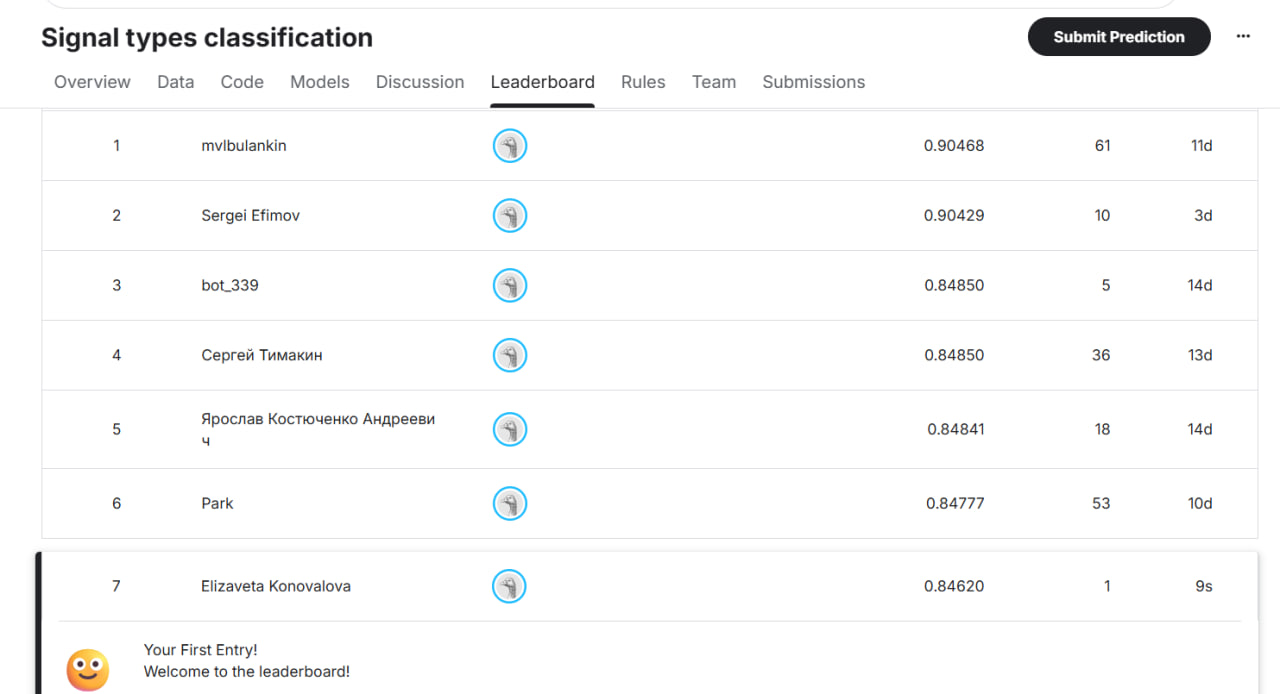

# Описание проекта

Целью данной работы является автоматическая кластеризация сигналов, полученных со сцинтилляционного детектора, на основе их параметров. 

Исходные данные представлены набором сигналов, каждый из которых описывается вектором признаков (временных параметров).

Задача: необходимо разделить 23 479 сигналов на три кластера: два из них соответствуют различным типам частиц (гамма-кванты и нейтроны), а третий — группе аномальных или неидентифицируемых сигналов.

Задача решается методами машинного обучения без учителя с последующей интерпретацией результатов кластеризации.

# Импорты

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

In [2]:
SEED = 42

np.random.seed(SEED)

# EDA 

In [3]:
df = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
df = df.drop([0, 1, 2, 3, 504], axis=1)
df.columns = list(range(500))
df.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


Каждая строка датасета представляет из себя временную форму сигнала длинной 500 АЦП.

In [4]:
print(f"Размерность датасета: {df.shape}")

Размерность датасета: (23479, 500)


### Визуализация исходных данных

Изобразим на графике 150 сигналов, уменьшив рассматриваемый временной промежуток до 140-200ns. 

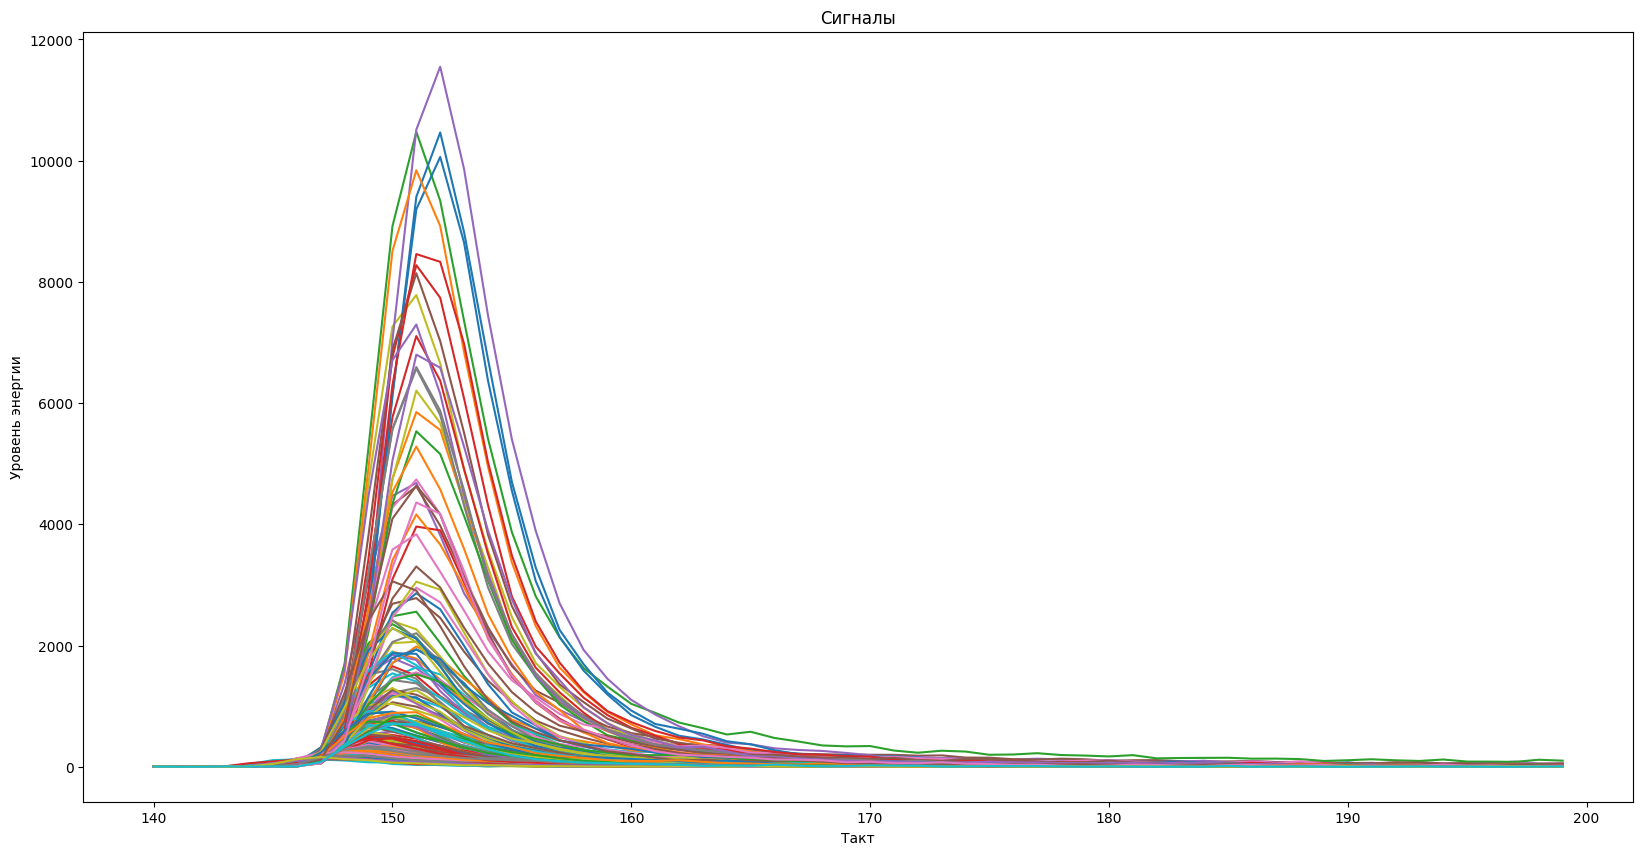

In [5]:
# Возьмем 150 сигналов 
N = range(0, 150)

# Преобразуем датасет так, чтобы чтобы состояние отсутствия сигнала распологалось около нуля
processed = 2 ** 14 - df # вычтем значения сигналов из максимального уровня 14-битного АЦП
baseline = processed.iloc[:, :50].median(axis=1) # рассчитаем среднее значение шума детектора
processed = processed.sub(baseline, axis=0).clip(lower=0)

ax = processed.iloc[N].T[140:200].plot(title='Сигналы', legend=None, figsize=(20,10))
ax.set_xlabel("Такт")
ax.set_ylabel("Уровень энергии")
plt.show()

График демонстирует нарастание и спад сигналов в промежутке времени 140-200ns. Можно заметить, что нарастание сигналов происходит резко и практически одновременно, в то время как спад сигналов проходит намного плавнее, дольше и разнообразнее.

In [6]:
print(f"Количество пропусков в датасете: {df.isna().sum().sum()}")

Количество пропусков в датасете: 0


### Вариативность сигналов

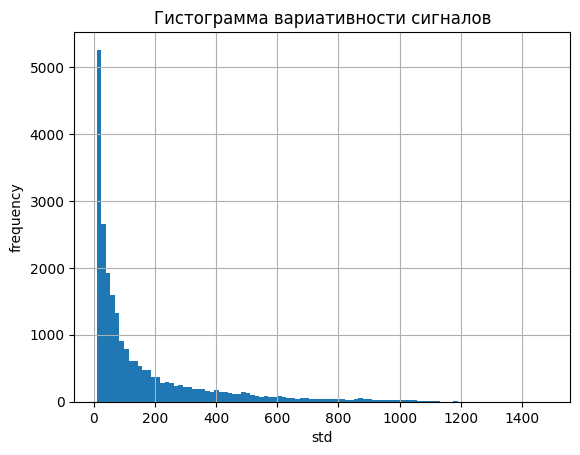

In [7]:
stds = df.std(axis=1)
stds.hist(bins=100)
plt.xlabel('std')
plt.ylabel('frequency')
plt.title('Гистограмма вариативности сигналов')
plt.show()

Распределение стандартного отклонения сигналов имеет выраженную правостороннюю ассиметрию и длинный хвост, что указывает на существенную вариативность амплитуд импульсов и неоднородность зарегистрированных событий. Более 5000 сигналов отличаются низкоэнергетическими импульсами, которые могут быть шумом или просто слабыми событиями. Длинный хвост справа, достигающий значений 1200 и свидетельствующий о наличии сигналов с очень мощным импульсом. 

### PSD

Для различия двух типов сигнала построим PSD гистограмму. 

PSD вычисляется как отношение площади "хвоста" сигнала (момент спада) к общей площади сигнала:

$$PSD=\frac{\text{tail area}}{\text{total area}}$$

Это отношение похволяет разделить сигналы на типы, поскольку у сигналов, вызванных разными частицами различается характер спада, т.к. они по разному возбуждают сцинтиллятор: у сигналов гамма-квант спад более резкий и быстрый, в то время как сигналы нейтронов затухают медленнее. Ввиду этой особенности и имеет смысл попробовать разделить сигналы методом PSD.

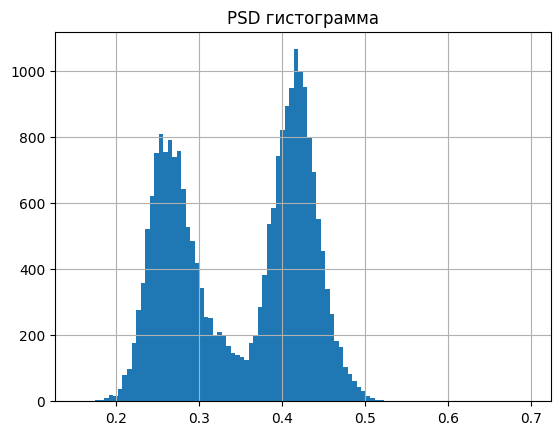

In [8]:
total_signal_area = processed.sum(axis=1) # площадь области под импульсами 
tail_area = processed.iloc[:, 155:].sum(axis=1)
PSD = tail_area / total_signal_area
PSD.hist(bins=100)
plt.title('PSD гистограмма')
plt.show()

PSD гистограмма иллюстрирует присутствие в датасете двух выраженных групп сигналов, различающихся по отношению площади хвостовой части импульса к полной площади сигнала. Левый пик соответствует сигналам с меньшим вкладом хвостовой компоненты, что характерно для гамма-квантов, в то время как правый пик соответствует сигналам с более выраженным хвостом, характерным для нейтронов.

Эксперементальным путем было определено оптимальное начало "хвоста" сигналов для достижимости наилучшей разделимости групп сигналов, этим значением оказался 155 такт. 

Таким образом, наличие двух отчетливо разделенных максимумов подтверждает возможность разделения типов частиц на основе формы сцинтилляционного импульса при помощи метода PSD.

### Амплитуда и площадь под сигналом

Построим диаграму рассеяния зависимости амплитуды от площади под сигналом. 

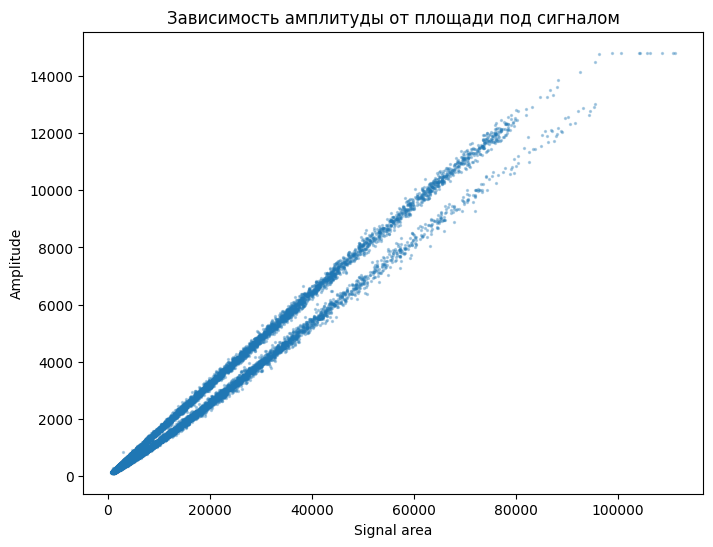

In [9]:
amp = processed.max(axis=1)
area = processed.iloc[:, 140:250].sum(axis=1)

plt.figure(figsize=(8,6))

plt.scatter(area, amp, s=2, alpha=0.3)

plt.xlabel('Signal area')
plt.ylabel('Amplitude')
plt.title('Зависимость амплитуды от площади под сигналом')

plt.show()

Диаграма рассеяния амплитуды сигнала от площади под импульсом демонстрирует наличие двух выраженных зависимостей, соответствующих различным типам происхождения сигнала. Для сигналов с одинаковой амплитудой наблюдаются различия в полной площади импульса, что указывает на различную длительность хвостовой компоненты и подтверждает возможность разделения на гамма-кванты и нейтроны по форме сигнала. 

## Вывод

В результате разведочного анализа данных были получены следующие выводы:

- Сигналы, зафиксированные сцинтилляционным детектором, возможно разделить на группы по природе их происхождения (гамма-кванты и нейтроны), используя метод PSD (Pulse Shape Discrimination). Наличие двух явно выраженных пиков на PSD гистограмме свидетельствует о различии временных характеристик затухания для разных типов частиц.
- Анализ зависимости амплитуды сигнала от площади под импульсом привел нас к выводу о полезности для модели соответствующих признаков, что подтверждает диаграмма рассеяния упомянутой зависимости, продемонстрировавшая выраженную разделимость сигналов на два типа. 
- Наличие разделимых групп сигналов позволяет предположить возможность успешного применения методов кластеризации и снижения размерности, в частности метода главных компонент (PCA), для автоматического разделения сигналов по типу частиц.
- То обстоятельство, что рассматриваемые сигналы представляют из себя смесь независимых источников, позволяет предположить также возможность применения метода независимых компонент (ICA), который направлен на поиск статистически независимых скрытых негауссовских компонент сигнала.

# Предобработка данных

На этапе предобработки данных мы сперва преобразуем датасет так, чтобы отсутствие сигнала располагалось около 0. В качестве baseline (уровень, когда сигнал отсутствует) возьмем медиану по периоду первых 50 тактов. 

Далее выполняется нормализация сигналов по максимульной амплитуде, что позволяет уменьшить влияние мощности импульсов и сфокусироваться на различиях в форме сигналов и особенностях их затухания на этапе кластеризации.

In [10]:
def preprocess(signals, bits=14):
    signals = 2 ** bits - signals
    # baseline subtraction
    baseline = signals.iloc[:, :50].median(axis=1)
    signals = signals.sub(baseline, axis=0)
    
    # normalization 
    normalized = signals.div(signals.max(axis=1), axis=0)

    return normalized

In [11]:
preprocessed = preprocess(df)

## Вывод

# Feature Engineering

Создадим информативные для модели признаки, которые помогут разделить сигналы на отдельные кластеры. В числе выбранных нами признаков нахоядтся: стандартное отклонение сигнала, эксцесс, FWHM (полная ширина на половине максимума), PSD.

In [12]:
def fwhm(signal):
    signal = np.asarray(signal)
    half_max = signal.max() / 2
    indices = np.where(signal >= half_max)[0]
    if len(indices) < 2:
        return 0
    return indices[-1] - indices[0]

def make_features(signals, tail_threshold):
    features = pd.DataFrame(index=signals.index)
    
    # базовые статистики
    features['std'] = signals.std(axis=1)
    features['kurt'] = signals.kurt(axis=1)
    
    # амплитуда
    amp = signals.max(axis=1)
    
    # площадь под импульсом
    area = signals.sum(axis=1)
    
    # PSD 
    tail = signals.iloc[:, tail_threshold:].sum(axis=1)
    features['PSD'] = tail / area

    # FWHM
    features['FWHM'] = signals.apply(fwhm, axis=1)
    
    return features

In [13]:
features = make_features(preprocessed, 155)
signal = preprocessed.iloc[:, 150:200]

X = pd.concat([signal, features], axis=1)

In [14]:
X.describe()

,150,151,152,153,154,155,156,157,158,159,...,194,195,196,197,198,199,std,kurt,PSD,FWHM
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,0.867432,0.807310,0.660075,0.502369,0.372027,0.277782,0.212323,0.166611,0.132798,0.108236,...,0.010826,0.010304,0.010070,0.009868,0.009664,0.009326,0.089466,77.786377,0.303738,4.245539
std,0.159086,0.207848,0.210743,0.172751,0.127271,0.092776,0.071263,0.058519,0.049948,0.043871,...,0.013537,0.013208,0.013225,0.012957,0.012810,0.012879,0.004909,9.823000,0.369423,2.215434
min,0.186147,0.090909,0.065789,0.049296,0.003534,-0.031008,-0.027523,-0.033898,-0.041096,-0.047170,...,-0.060606,-0.061728,-0.074830,-0.061538,-0.059211,-0.067164,0.063154,41.815727,-41.583333,2.000000
25%,0.791015,0.675383,0.503067,0.373333,0.279242,0.211214,0.161290,0.125192,0.096335,0.075949,...,0.003306,0.003113,0.003003,0.002915,0.002810,0.002645,0.086216,70.753813,0.238147,4.000000
50%,0.923567,0.878141,0.689456,0.512573,0.380054,0.286504,0.218045,0.169014,0.132153,0.104623,...,0.008969,0.008375,0.008247,0.008000,0.007874,0.007563,0.088908,78.379445,0.315020,4.000000
75%,1.000000,1.000000,0.834939,0.635326,0.466120,0.347956,0.268025,0.213263,0.172592,0.143075,...,0.016707,0.016077,0.015812,0.015432,0.015212,0.014706,0.092284,86.081816,0.408793,5.000000
max,1.000000,1.000000,1.000000,1.000000,0.998313,0.720907,0.505903,0.398374,0.339869,0.335849,...,0.136364,0.125475,0.140351,0.151261,0.118644,0.147287,0.117350,163.578035,5.269663,326.000000


Признаки различаются по диапазону значений, поэтому стандартизируем их.

In [15]:
scaler = StandardScaler()

X.columns = X.columns.astype(str)
X_std = scaler.fit_transform(X)
X_df = pd.DataFrame(X_std, index=X.index, columns=X.columns)
X_df.describe()

,150,151,152,153,154,155,156,157,158,159,...,194,195,196,197,198,199,std,kurt,PSD,FWHM
count,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,...,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04,2.347900e+04
mean,2.887081e-16,-8.815584e-16,2.281823e-16,5.992055e-17,5.314166e-16,1.193872e-16,2.148666e-17,-2.850766e-16,-1.979194e-16,2.348401e-16,...,2.057878e-17,7.202571e-17,-7.384149e-17,1.876300e-17,9.744655e-17,-3.026290e-17,-9.929259e-16,-3.682995e-16,-7.868355e-18,5.447323e-17
std,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,...,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00,1.000021e+00
min,-4.282572e+00,-3.446830e+00,-2.820010e+00,-2.622757e+00,-2.895399e+00,-3.328419e+00,-3.365709e+00,-3.426448e+00,-3.481576e+00,-3.542372e+00,...,-5.276844e+00,-5.453900e+00,-6.419739e+00,-5.511284e+00,-5.376922e+00,-5.939414e+00,-5.359841e+00,-3.661958e+00,-1.133875e+02,-1.013610e+00
25%,-4.803559e-01,-6.347446e-01,-7.450348e-01,-7.469649e-01,-7.290518e-01,-7.175287e-01,-7.161326e-01,-7.078059e-01,-7.300236e-01,-7.359534e-01,...,-5.555535e-01,-5.444757e-01,-5.343710e-01,-5.366120e-01,-5.350904e-01,-5.188081e-01,-6.620948e-01,-7.159435e-01,-1.775526e-01,-1.108333e-01
50%,3.528683e-01,3.407862e-01,1.394193e-01,5.906440e-02,6.306923e-02,9.401158e-02,8.029523e-02,4.106567e-02,-1.290554e-02,-8.236015e-02,...,-1.371738e-01,-1.460624e-01,-1.378654e-01,-1.441772e-01,-1.397288e-01,-1.369000e-01,-1.137615e-01,6.037675e-02,3.054150e-02,-1.108333e-01
75%,8.333290e-01,9.270891e-01,8.297670e-01,7.696592e-01,7.393283e-01,7.564068e-01,7.816571e-01,7.972236e-01,7.967283e-01,7.941386e-01,...,4.344669e-01,4.370853e-01,4.341961e-01,4.294459e-01,4.331636e-01,4.177377e-01,5.739433e-01,8.445093e-01,2.843827e-01,3.405552e-01
max,8.333290e-01,9.270891e-01,1.613014e+00,2.880689e+00,4.920978e+00,4.776410e+00,4.119743e+00,3.960533e+00,4.145841e+00,5.188285e+00,...,9.273721e+00,8.720075e+00,9.851268e+00,1.091293e+01,8.507929e+00,1.071255e+01,5.680193e+00,8.733939e+00,1.344266e+01,1.452363e+02


Спроецирем отобранные и созданные производные признаки в 2D пространство при помощи алгоритма UMAP, чтобы посмотреть на разделимость кластеров:

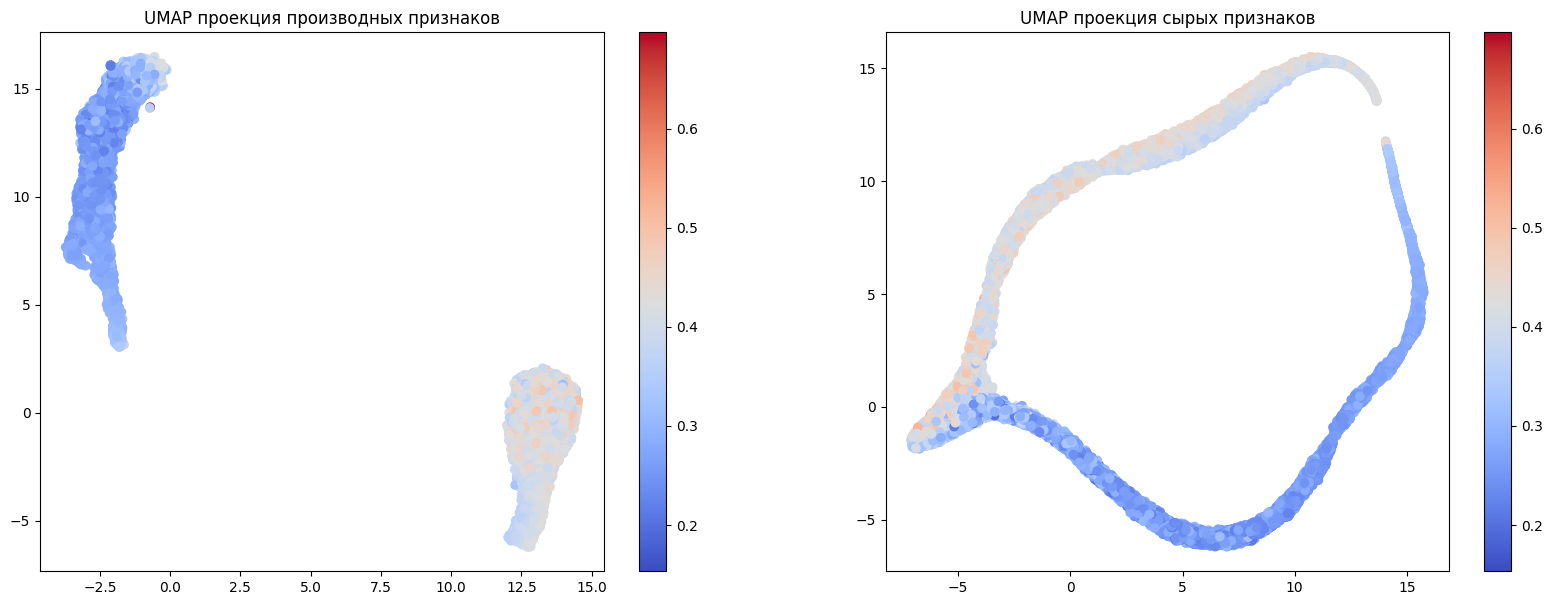

In [20]:
umap_reducer = UMAP(n_components=2, n_neighbors=40, min_dist=0.1,  metric='cosine', random_state=SEED, n_jobs=1)

# производные признаки
umap_fe = umap_reducer.fit_transform(X_df)

# сырые признаки (сигналы)
umap_raw = umap_reducer.fit_transform(processed)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sc1 = axes[0].scatter(umap_fe[:, 0], umap_fe[:, 1], c=PSD, cmap='coolwarm')
axes[0].set_title('UMAP проекция производных признаков')
fig.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(umap_raw[:, 0], umap_raw[:, 1], c=PSD, cmap='coolwarm')
axes[1].set_title('UMAP проекция сырых признаков')
fig.colorbar(sc2, ax=axes[1])

plt.show()

UMAP проекция производных и отобранных признаков демонстрирует, что сигналы четко разделяются на два физически неслучайных кластера (о неслучайности чего свидетельствует цвет точек, окрашенных согласно PSD значениям сигналов), поэтому для разбивки сигналов на два кластера кажется целесообразным использовать полученное при помощи нормализации, производных признаков, сырых сигналов и UMAP проекции двумерное пространство.  

## Вывод

На этапе Feature Engineering нами были извлечену следующие признаки: стандартное отклонение сигналов, эксцесс, FWHM и PSD, и также добавлены сырые сигналы с участка, где сигналы достигают пика и начинают затухать (такты 155-200). Визуализация проекции UMAP на двумерное пространство продемонстрировало целесообразность использования данных признаков для разделения сигналов на два кластера.

# Baseline модель

В качестве baseline модели мы будем использовать KMaans, поскольку кластеры хорошо разделимы, и будем разделять данные на два кластера, используя в качестве признакового пространства 2D UMAP проекцию производных и отобранных на предыдущем этапе признаков. 

## Kmeans

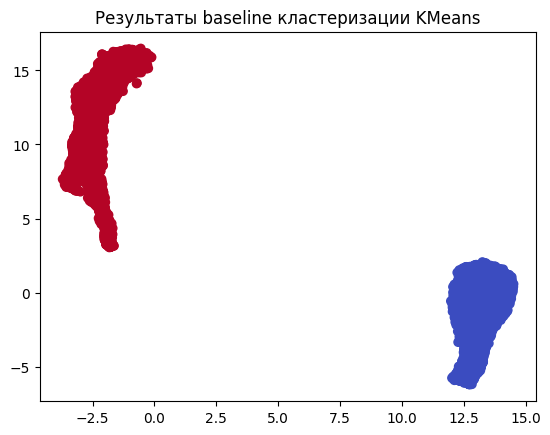

In [33]:
km = KMeans(n_clusters=2, random_state=SEED)

km.fit(umap_fe)
km_labels = km.predict(umap_fe)

# plot
plt.scatter(umap_fe[:, 0], umap_fe[:, 1], c=km_labels, cmap='coolwarm')
plt.title('Результаты baseline кластеризации KMeans')
plt.show()

Посмотрим на сигналы, определенные в разные кластеры:

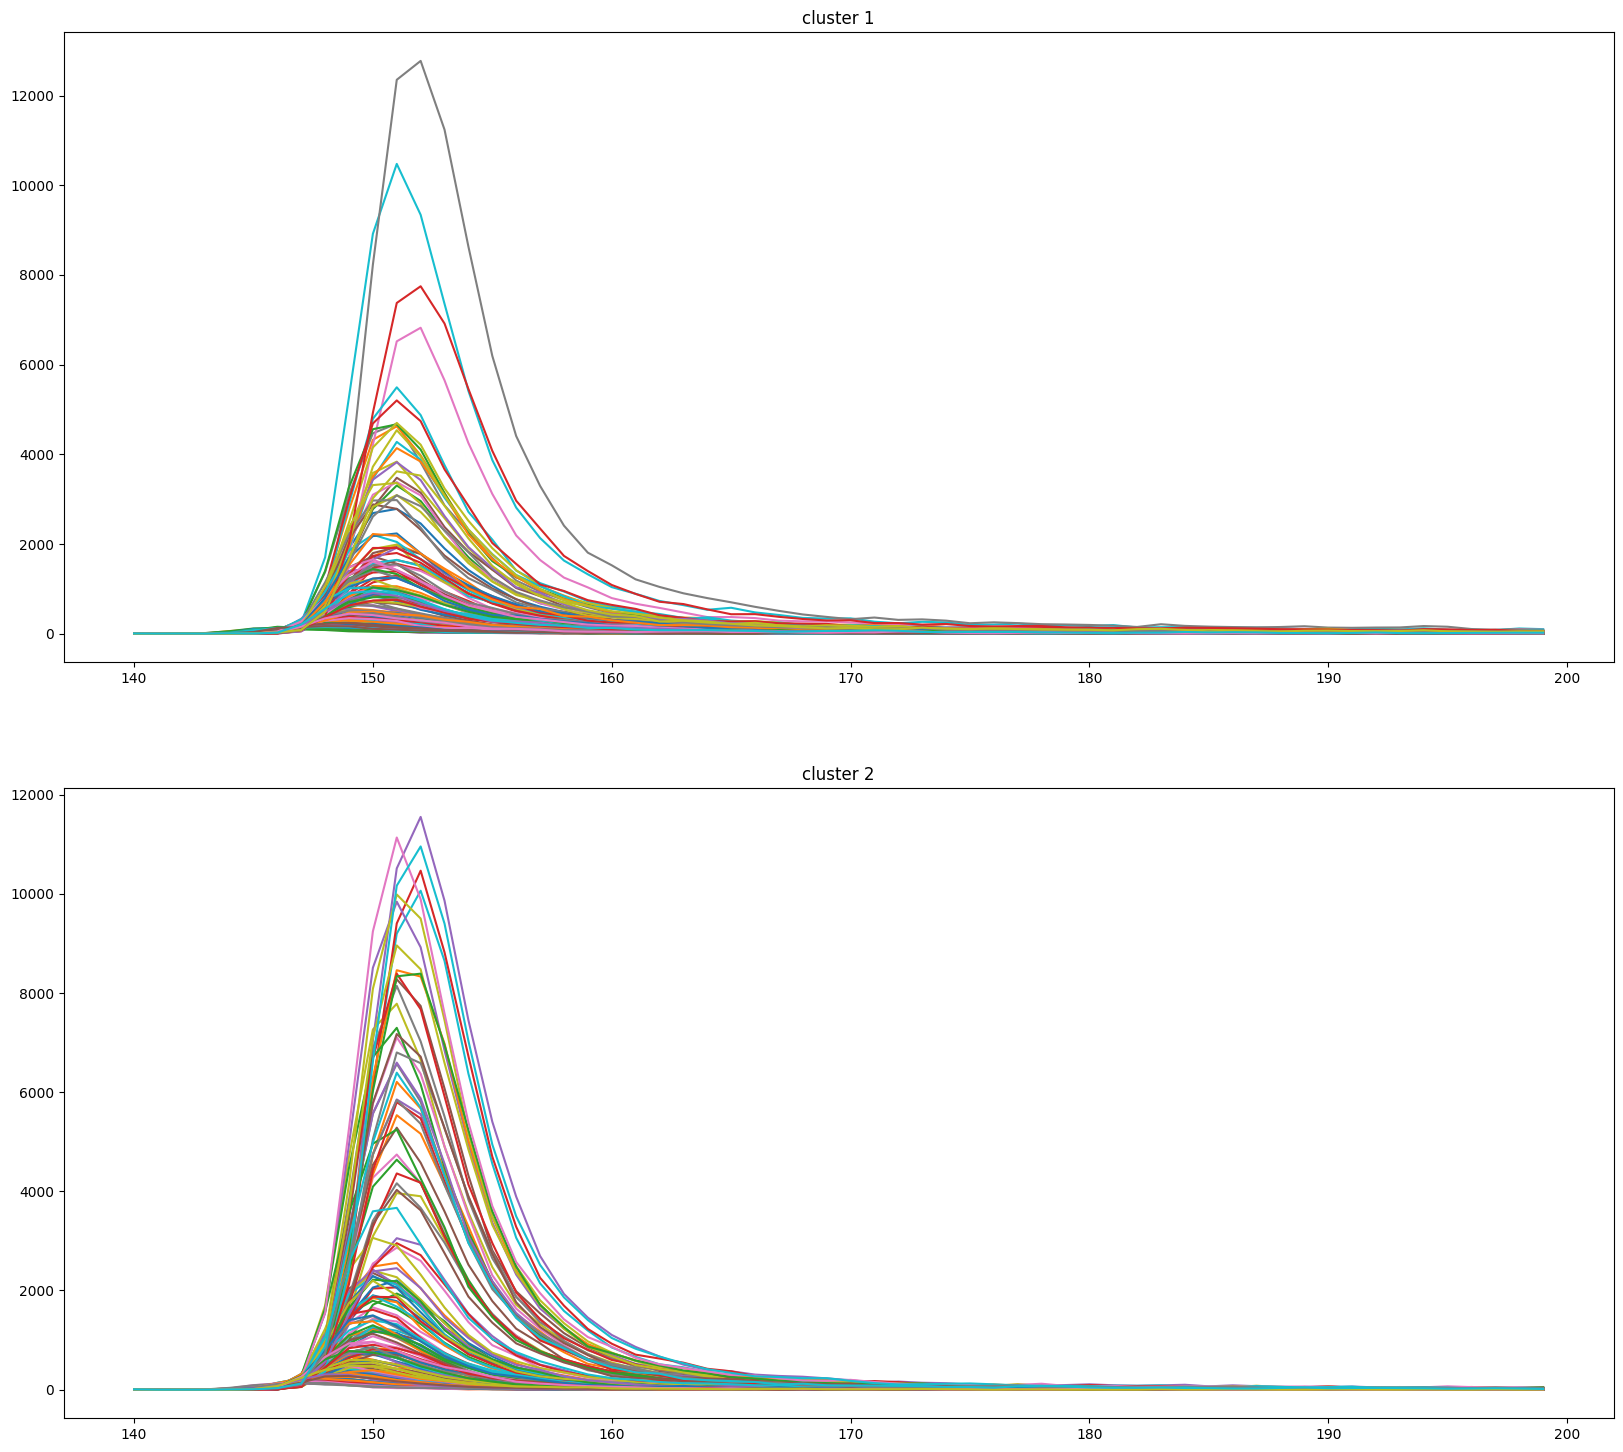

In [34]:
cluster0 = processed[km_labels == 0]
cluster1 = processed[km_labels == 1]

fig, axes = plt.subplots(2, 1, figsize=(20, 18))

cluster0.iloc[range(0, 150)].T[140:200].plot(legend=None, ax=axes[0])
axes[0].set_title("cluster 1")
cluster1.iloc[range(0, 150)].T[140:200].plot(legend=None, ax=axes[1])
axes[1].set_title("cluster 2")
plt.show()

Разделение на кластеры выглядит весьма физически осмысленным: первый график демонстрирует сигналы с более длинными хвостами, в то время как сигналы на втором графике затухают быстрее. По данному наблюдению можно предположить, что в первый кластер попали нейтроны, а во второй гамма-кванты. 

In [35]:
np.unique(km_labels)

array([0, 1], dtype=int32)

In [36]:
submission = pd.DataFrame({"cluster": km_labels}).reset_index()
submission.head()

,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


In [202]:
submission.to_csv("submission_gamma_neutrons.csv", index=False)

Результат разделения сигналов на два кластера с использованием проведенным Feature Engineering-ом, UMAP сжатием в двумерное пространство и кластеризацией алгоритмом KMeans показал 0.84620 accuracy на лидерборде, что означает, что мы движемся в правильном направлении. 

На данный момент мы добились достаточно хорошего разделения сигналов на два типа, однако в каждом из кластров еще фигурирует шум, который необходимо отделить от основной массы сигналов и обозначить в третий кластер. 

# Noise

# Обучение нескольких моделей и подбор гиперпараметров 

# Выбор лучшей модели и объяснение выбора

# Предсказание

# Общие выводы к решению и интерпретация полученных результатов